# MHEALTH dataset

Enlace al dataset: https://archive.ics.uci.edu/dataset/319/mhealth+dataset

In [1]:
# Importacion de librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

## Importación del dataset

In [70]:
data_path = "C:/Users/C-Ramirez/Documents/LCC/RAHBFDP/ProyectoFinal/MHEALTHDATASET" #Cram
#data_path = "C:/Users/david/Documents/FD/MHEALTHDATASET" #David

In [55]:
with open(data_path+"/README.txt",'r',encoding="ansi") as readme:
    txt = readme.read()
    print(txt)


*************************************************** mHealth dataset **********************************************************

Authors: Oresti Baños, Rafael Garcia, Alejandro Saez
Date: 22/10/2013
Institution: University of Granada (UGR) 
Department: Department of Computer Architecture and Computer Technology.
Contact: oresti@ugr.es (oresti.bl@gmail.com)

---------------------------------------------------------------------------------------------------------------------------------------------
NOTE: if you use this dataset please cite the following work

Banos, O., Garcia, R., Holgado-Terriza, J.A., Damas, M., Pomares, H., Rojas, I., Saez, A., Villalonga, C.: 
mHealthDroid: a novel framework for agile development of mobile health applications. 
In: Proceedings of the 6th International Work-conference on Ambient Assisted Living an Active Ageing (IWAAL 2014), Belfast, United Kingdom, December 2-5 (2014)

Insightful figures and descriptions are presented within this work.
-------------

In [110]:
# Nombres de las columnas
column_names = ["subject","acc_chest_x","acc_chest_y","acc_chest_z", 
    "electrocardiogram_l1","electrocardiogram_l2", "acc_left_ankle_x", "acc_left_ankle_y", "acc_left_ankle_z", 
    "gyro_left_ankle_x", "gyro_left_ankle_y", "gyro_left_ankle_z", 
    "MAG_left_ankle_x", "MAG_left_ankle_y", "MAG_left_ankle_z",
    "acc_r_lw_arm_x","acc_r_lw_arm_y","acc_r_lw_arm_z",
    "gyro_r_lw_arm_x","gyro_r_lw_arm_y","gyro_r_lw_arm_z",
    "MAG_r_lw_arm_x","MAG_r_lw_arm_y","MAG_r_lw_arm_z",
    "label"
    ]
# Creacion de dataframe vacio
data = pd.DataFrame(columns=column_names)

In [111]:
# Carga de datasets de cada sujeto y concatenación en un mismo dataframe
for i, file in enumerate(os.listdir(data_path)):
    if file != "README.txt":
        df_tmp = pd.read_csv(os.path.join(data_path, file), header=None, sep="\t")
        df_tmp.columns = column_names[1:]
        df_tmp["subject"] = i+1
        data = pd.concat([data, df_tmp])
        

C:\Users\C-Ramirez\AppData\Local\Temp\ipykernel_15540\1758140931.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat([data, df_tmp])


## Dimensiones del dataset y primeras 5 líneas

In [73]:
data.shape

(1215745, 25)

In [7]:
data.head()

,subject,acc_chest_x,acc_chest_y,acc_chest_z,electrocardiogram_l1,electrocardiogram_l2,acc_left_ankle_x,acc_left_ankle_y,acc_left_ankle_z,gyro_left_ankle_x,...,acc_r_lw_arm_x,acc_r_lw_arm_y,acc_r_lw_arm_z,gyro_r_lw_arm_x,gyro_r_lw_arm_y,gyro_r_lw_arm_z,MAG_r_lw_arm_x,MAG_r_lw_arm_y,MAG_r_lw_arm_z,label
0,1,-9.8184,0.009971,0.29563,0.004186,0.004186,2.1849,-9.6967,0.63077,0.103900,...,-8.6499,-4.5781,0.187760,-0.44902,-1.0103,0.034483,-2.35000,-1.610200,-0.030899,0
1,1,-9.8489,0.524040,0.37348,0.004186,0.016745,2.3876,-9.5080,0.68389,0.085343,...,-8.6275,-4.3198,0.023595,-0.44902,-1.0103,0.034483,-2.16320,-0.882540,0.326570,0
2,1,-9.6602,0.181850,0.43742,0.016745,0.037677,2.4086,-9.5674,0.68113,0.085343,...,-8.5055,-4.2772,0.275720,-0.44902,-1.0103,0.034483,-1.61750,-0.165620,-0.030693,0
3,1,-9.6507,0.214220,0.24033,0.079540,0.117220,2.1814,-9.4301,0.55031,0.085343,...,-8.6279,-4.3163,0.367520,-0.45686,-1.0082,0.025862,-1.07710,0.006945,-0.382620,0
4,1,-9.7030,0.303890,0.31156,0.221870,0.205130,2.4173,-9.3889,0.71098,0.085343,...,-8.7008,-4.1459,0.407290,-0.45686,-1.0082,0.025862,-0.53684,0.175900,-1.095500,0


## Datos ausentes

Primero debemos verificar si nuestro dataset tiene presencia o no de datos nulos:

In [8]:
data.isnull().sum() # Conteo de nulos por columna

subject                 0
acc_chest_x             0
acc_chest_y             0
acc_chest_z             0
electrocardiogram_l1    0
electrocardiogram_l2    0
acc_left_ankle_x        0
acc_left_ankle_y        0
acc_left_ankle_z        0
gyro_left_ankle_x       0
gyro_left_ankle_y       0
gyro_left_ankle_z       0
MAG_left_ankle_x        0
MAG_left_ankle_y        0
MAG_left_ankle_z        0
acc_r_lw_arm_x          0
acc_r_lw_arm_y          0
acc_r_lw_arm_z          0
gyro_r_lw_arm_x         0
gyro_r_lw_arm_y         0
gyro_r_lw_arm_z         0
MAG_r_lw_arm_x          0
MAG_r_lw_arm_y          0
MAG_r_lw_arm_z          0
label                   0
dtype: int64

En este caso notamos que ninguna columna cuenta con valores nulos, por lo tanto seguimos adelante con el proceso.

## Tipos de datos por atributo

In [9]:
data.dtypes # Desplegar tipos de datos de cada atributo

subject                  object
acc_chest_x             float64
acc_chest_y             float64
acc_chest_z             float64
electrocardiogram_l1    float64
electrocardiogram_l2    float64
acc_left_ankle_x        float64
acc_left_ankle_y        float64
acc_left_ankle_z        float64
gyro_left_ankle_x       float64
gyro_left_ankle_y       float64
gyro_left_ankle_z       float64
MAG_left_ankle_x        float64
MAG_left_ankle_y        float64
MAG_left_ankle_z        float64
acc_r_lw_arm_x          float64
acc_r_lw_arm_y          float64
acc_r_lw_arm_z          float64
gyro_r_lw_arm_x         float64
gyro_r_lw_arm_y         float64
gyro_r_lw_arm_z         float64
MAG_r_lw_arm_x          float64
MAG_r_lw_arm_y          float64
MAG_r_lw_arm_z          float64
label                    object
dtype: object

## Resumen estadístico del dataset

#### Resumen general:

In [10]:
pd.options.display.float_format = '{:.4f}'.format ## Desplegar resultados con 4 decimales de precisión
print(data.describe()) # Imprimir resumen estadístico

       acc_chest_x  acc_chest_y  acc_chest_z  electrocardiogram_l1  \
count 1215745.0000 1215745.0000 1215745.0000          1215745.0000   
mean       -8.5224      -0.2140      -1.0559               -0.0051   
std         4.0753       2.1390       3.5742                0.7466   
min       -22.4380     -20.1880     -18.4010               -8.6196   
25%        -9.8040      -1.2729      -2.8673               -0.2344   
50%        -9.3114      -0.3538      -0.8702               -0.0712   
75%        -7.6371       0.7098       0.7259                0.1591   
max        19.0940      20.9270      26.1960                8.5149   

       electrocardiogram_l2  acc_left_ankle_x  acc_left_ankle_y  \
count          1215745.0000      1215745.0000      1215745.0000   
mean                -0.0045            1.4942           -9.6929   
std                  0.7270            3.8265            4.1713   
min                 -8.6196          -22.1460          -19.6190   
25%                 -0.1884       

A primera vista podemos notar que los datos que nos brindan una mayor variabilidad son, en su mayoría, aquellos proporcionados por los acelerómetros y magnetómetros (mayor desviación estándar / std). 

De igual forma, basándonos en los mínimos y máximos de cada característica, podemos observar una gran diferencia de escalas en algunos casos, por lo que se abre la posibilidad de tener que realizar un reescalado de características.

#### Resumen por sujeto:

In [11]:
pd.options.display.float_format = '{:.3f}'.format ## Desplegar resultados con 4 decimales de precisión
data.groupby("subject").describe() # Imprimir resumen estadístico por sujeto

acc_chest_x                                                    \
              count   mean   std     min     25%    50%    75%    max   
subject                                                                 
1        161280.000 -8.738 3.806 -22.303  -9.833 -9.331 -8.021 18.960   
2         98304.000 -8.417 4.094 -22.139  -9.758 -9.175 -6.629 17.618   
3        130561.000 -8.859 3.601 -22.295  -9.871 -9.399 -8.219 16.526   
4        122112.000 -8.332 4.145 -22.438  -9.823 -9.156 -7.248 19.065   
5        116736.000 -7.831 4.278 -22.259  -9.694 -9.073 -6.633 19.094   
6        119808.000 -8.647 4.315 -22.168 -10.006 -9.373 -7.736 19.082   
7         98304.000 -8.633 4.007 -22.321  -9.829 -9.468 -7.912 14.857   
8        104448.000 -8.440 4.185 -22.266  -9.743 -9.375 -7.577 18.975   
9        129024.000 -8.558 3.976 -22.289  -9.698 -9.191 -8.246 17.204   
10       135168.000 -8.625 4.312 -22.306  -9.835 -9.464 -7.538 19.078   

        acc_chest_y         ... MAG_r_lw_arm_y         MAG_r_lw_arm_z         \
              count   mean  ...            75%     max          count   mean   
subject                     ...                                                
1        161280.000  0.186  ...         10.905 334.980     161280.000 -0.231   
2         98304.000  0.201  ...         10.136 332.060      98304.000 -0.840   
3        130561.000 -0.187  ...          9.472 336.220     130561.000 -0.041   
4        122112.000  0.004  ...         12.619 337.760     122112.000  0.380   
5        116736.000 -0.190  ...         12.067 335.250     116736.000 -0.592   
6        119808.000 -0.419  ...         11.873 334.450     119808.000 -0.384   
7         98304.000 -0.224  ...          7.673 330.420      98304.000 -0.738   
8        104448.000 -0.333  ...          7.628 331.170     104448.000 -0.301   
9        129024.000 -0.375  ...          8.212 334.120     129024.000 -0.097   
10       135168.000 -0.802  ...         10.358 336.120     135168.000 -1.003   

                                                       
           std      min     25%    50%    75%     max  
subject                                                
1       62.555 -697.160 -13.399 -0.370 12.793 629.950  
2       60.940 -504.800 -15.257 -0.715 14.133 616.930  
3       66.663 -601.630 -14.314 -0.359 13.170 506.320  
4       79.465 -607.100 -16.956 -0.359 17.996 657.180  
5       52.193 -615.100 -13.306 -0.361 12.359 655.860  
6       74.031 -678.360 -19.639 -0.718 16.425 519.590  
7       69.244 -680.820 -14.988 -0.716 13.703 585.170  
8       59.335 -453.910 -10.596 -0.377  9.195 440.690  
9       72.850 -717.550  -9.780 -0.602  8.418 626.590  
10      87.499 -668.430 -16.811 -0.713 15.237 602.580  

[10 rows x 184 columns]

Podemos notar estadísticas similares a las generales en su mayoría.

## Distribución de clases

#### Distribución general:

In [12]:
class_freq = data.groupby("label").size() # Agrupar por label y desplegar conteo
class_freq

label
0     872550
1      30720
2      30720
3      30720
4      30720
5      30720
6      28315
7      29441
8      29337
9      30720
10     30720
11     30720
12     10342
dtype: int64

In [12]:
print(f"Porcentaje de la clase 0: {class_freq[0]/class_freq.sum()*100}%")

Porcentaje de la clase 0: 71.77080720052314%


Podemos darnos cuenta de que nuestro dataset está desbalanceado, pues el 70% de nuestros datos corresponde a la clase de actividad nula (0). En este caso, nosotros decidimos aplicar un undersampling de esta clase, proceso que será mostrado más adelante.

Sin embargo, se debe notar que la actividad 12 también está presente una cantidad menor de veces que el resto, por lo que es un factor a tomar en cuenta al seleccionar un modelo, o resamplear los datos.

#### Distribución por sujeto:

In [13]:
class_freq_p_subject = data.groupby(["subject","label"]).size() # Agrupar por sujeto y label y desplegar conteo

In [14]:
pd.set_option("display.max_rows", None)  # Muestra todas las filas
print(class_freq_p_subject)

subject  label
1        0        126106
         1          3072
         2          3072
         3          3072
         4          3072
         5          3072
         6          3072
         7          3072
         8          3379
         9          3072
         10         3072
         11         3072
         12         1075
2        0         64614
         1          3072
         2          3072
         3          3072
         4          3072
         5          3072
         6          2458
         7          2765
         8          2867
         9          3072
         10         3072
         11         3072
         12         1024
3        0         95029
         1          3072
         2          3072
         3          3072
         4          3072
         5          3072
         6          3174
         7          3328
         8          3430
         9          3072
         10         3072
         11         3072
         12         1024
4        0

Podemos notar que la distribución de clases por sujeto es similar a la distribución de clases general, lo cual también se pudo apreciar en el resumen estadístico.

## Correlación entre atributos

In [15]:
print(data.corr()) # Desplegamos la correlacion de Pearson entre atributos

                      subject  acc_chest_x  acc_chest_y  acc_chest_z  \
subject                 1.000        0.005       -0.124        0.061   
acc_chest_x             0.005        1.000        0.075        0.178   
acc_chest_y            -0.124        0.075        1.000       -0.347   
acc_chest_z             0.061        0.178       -0.347        1.000   
electrocardiogram_l1    0.007        0.024        0.027       -0.010   
electrocardiogram_l2    0.011       -0.003        0.007       -0.010   
acc_left_ankle_x        0.077        0.050       -0.028        0.090   
acc_left_ankle_y       -0.007        0.306       -0.092        0.230   
acc_left_ankle_z        0.071        0.102       -0.100        0.235   
gyro_left_ankle_x       0.131        0.043       -0.038        0.048   
gyro_left_ankle_y       0.060        0.248       -0.120        0.250   
gyro_left_ankle_z       0.081        0.050       -0.174        0.230   
MAG_left_ankle_x        0.001        0.092       -0.036        0

Se puede ver que algunos atributos con una correlación considerable son:

- gyro_r_lw_arm_y con acc_r_lw_arm_y: 0.5921

- electrocardiogram_l1 con electrocardiogram_l2: 0.5965

- gyro_r_lw_arm_z con gyro_left_ankle_x: 0.5914

## Histogramas de los atributos

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

In [17]:
# Función para escoger un estilo y color aleatorio
def random_style():
    return random.choice(styles)

def random_color():
    return random.choice(colors)

### Histogramas de cada atributo por persona

In [19]:
#output_dir = 'C:/Users/david/Documents/FD_IMAGENES/HISTOGRAMAS_SUJETOS'
output_dir = 'C:/Users/C-Ramirez/Documents/LCC/RAHBFDP/ProyectoFinal/HISTOGRAMAS_SUJETOS'
os.makedirs(output_dir, exist_ok=True)

# Estilos y colores posibles
styles = ['whitegrid', 'darkgrid', 'white', 'dark', 'ticks']
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'pink', 'gray', 'cyan', 'magenta']

# Función para escoger un estilo y color aleatorio
def random_style():
    return random.choice(styles)

def random_color():
    return random.choice(colors)

attributes = data.columns.difference(['subject', 'label'])

# Histogramas por sujeto
for col in attributes:
    sns.set_style(random_style())
    color = random_color()
    
    plt.figure(figsize=(12, 8))
    
    g = sns.FacetGrid(data, col='subject', col_wrap=4, height=3, sharex=False, sharey=False)
    g.map(sns.histplot, col, bins='sturges', color=color, edgecolor='black')
    
    g.fig.suptitle(f'Histogramas de {col} por sujeto', fontsize=16, fontweight='bold', y=1.05)
    plt.savefig(f'{output_dir}/Histogramas de {col} por sujeto.png', bbox_inches='tight', facecolor='white')
    plt.close()

c:\Users\C-Ramirez\anaconda3\Lib\site-packages\seaborn\axisgrid.py:453: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)
C:\Users\C-Ramirez\AppData\Local\Temp\ipykernel_21684\3158125888.py:23: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12, 8))


<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

...

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

### Histogramas generales

In [142]:
output_dir = 'C:/Users/david/Documents/FD_IMAGENES/HISTOGRAMAS_GENERALES'
os.makedirs(output_dir, exist_ok=True)


attributes = data.columns.difference(['subject', 'label'])

# Histogramas generales para cada atributo
for col in attributes:
    color = random_color()
    plt.figure(figsize=(8, 5))
    sns.histplot(data[col], bins='sturges', color=color, edgecolor='black')
    
    plt.title(f'Histograma de {col}', fontsize=16, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    
    plt.savefig(f'{output_dir}/Histograma de {col}.png', bbox_inches='tight', facecolor='white')
    plt.close()

## Gráficas de densidad

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

### Gráficas de densidad individuales

In [152]:
output_dir = 'C:/Users/david/Documents/FD_IMAGENES/DENSIDAD_SUJETOS'
os.makedirs(output_dir, exist_ok=True)

for col in attributes:
    sns.set_style(random_style())
    color = random_color()
    
    plt.figure(figsize=(12, 8))
    
    g = sns.FacetGrid(data, col='subject', col_wrap=4, height=3, sharex=False, sharey=False)
    g.map(sns.kdeplot, col, fill=True, color=color)
    
    g.fig.suptitle(f'Gráfica de Densidad de {col} por sujeto', fontsize=16, fontweight='bold', y=1.05)
    plt.savefig(f'{output_dir}/Densidad de {col} por sujeto.png', bbox_inches='tight', facecolor='white')
    plt.close()

C:\Users\david\anaconda3\Lib\site-packages\seaborn\axisgrid.py:453: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)
C:\Users\david\AppData\Local\Temp\ipykernel_102148\3831397457.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12, 8))


<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

...

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

### Gráficas de densidad generales

In [146]:
output_dir = 'C:/Users/david/Documents/FD_IMAGENES/DENSIDAD_GENERAL'
os.makedirs(output_dir, exist_ok=True)

for col in attributes:
    sns.set_style(random_style())
    color = random_color()
    
    plt.figure(figsize=(12, 8))
    sns.kdeplot(data[col], color=color, fill=True)
    
    plt.title(f'Gráfica de Densidad de {col}', fontsize=16, fontweight='bold')
    plt.savefig(f'{output_dir}/Densidad de {col}.png', bbox_inches='tight', facecolor='white')
    plt.close()

## Gráficas de caja y bigotes

### Gráficas de densidad individuales

In [156]:
output_dir = 'C:/Users/david/Documents/FD_IMAGENES/BOXPLOT_SUJETOS'
os.makedirs(output_dir, exist_ok=True)

for col in attributes:
    sns.set_style(random_style())
    color = random_color()
    
    plt.figure(figsize=(12, 8))
    
    g = sns.FacetGrid(data, col='subject', col_wrap=4, height=3, sharex=False, sharey=False)
    g.map(sns.boxplot, col, color=color)
    
    g.fig.suptitle(f'Gráfica de Cajas y Bigotes de {col} por sujeto', fontsize=16, fontweight='bold', y=1.05)
    plt.savefig(f'{output_dir}/Boxplot de {col} por sujeto.png', bbox_inches='tight', facecolor='white')
    plt.close()

C:\Users\david\anaconda3\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
C:\Users\david\anaconda3\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
C:\Users\david\anaconda3\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
C:\Users\david\anaconda3\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
C:\Users\david\anaconda3\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

...

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

### Gráficas de caja y bigotes generales

In [157]:
output_dir = 'C:/Users/david/Documents/FD_IMAGENES/BOXPLOT_GENERAL'
os.makedirs(output_dir, exist_ok=True)

for col in attributes:
    sns.set_style(random_style())
    color = random_color()
    
    plt.figure(figsize=(12, 8))
    sns.boxplot(y=data[col], color=color)
    
    plt.title(f'Gráfica de Cajas y Bigotes de {col}', fontsize=16, fontweight='bold')
    plt.savefig(f'{output_dir}/Boxplot de {col}.png', bbox_inches='tight', facecolor='white')
    plt.close()


## Matrices de correlaciones

### Matrices de correlaciones generales

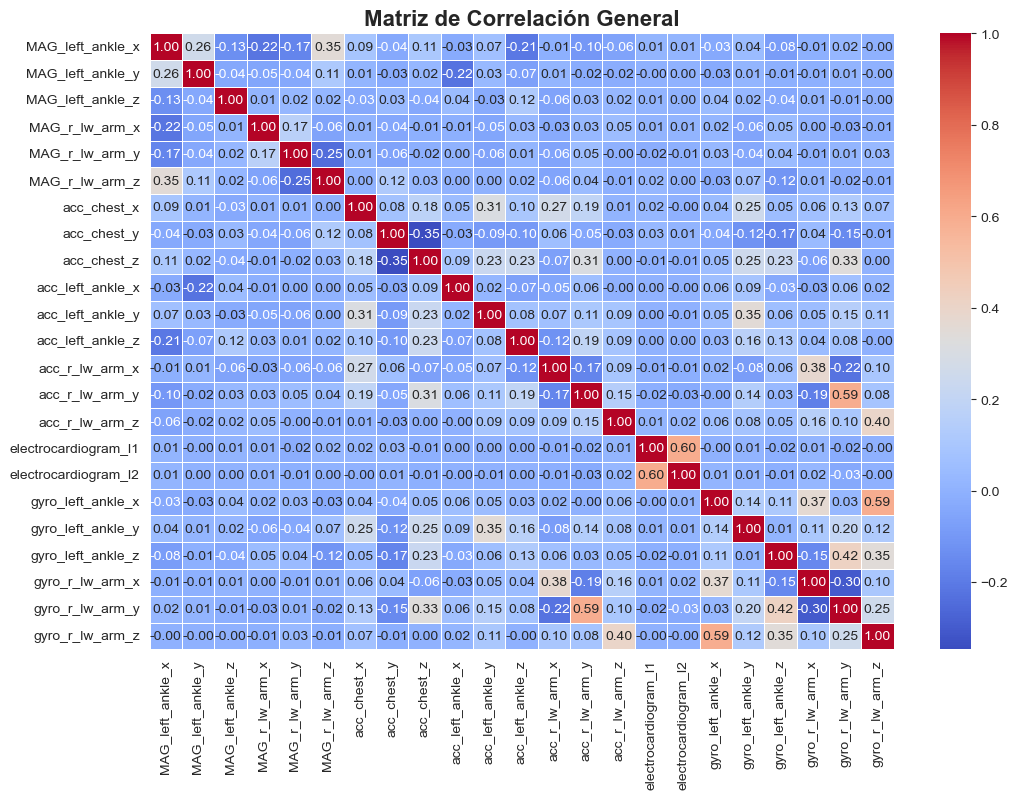

In [21]:
#output_dir = 'C:/Users/david/Documents/FD_IMAGENES/CORRELACION_GENERAL'
output_dir = 'C:/Users/C-Ramirez/Documents/LCC/RAHBFDP/ProyectoFinal/CORRELACION_GENERAL'
os.makedirs(output_dir, exist_ok=True)

sns.set_style(random_style())

plt.figure(figsize=(12, 8))
corr = data[attributes].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Matriz de Correlación General', fontsize=16, fontweight='bold')
plt.savefig(f'{output_dir}/Matriz de Correlación General.png', bbox_inches='tight', facecolor='white')
plt.show()
plt.close()


## Matrices de dispersión

### Matrices de dispersión generales

In [ ]:
output_dir = 'C:/Users/david/Documents/FD_IMAGENES/DISPERSION_GENERAL_2'
os.makedirs(output_dir, exist_ok=True)

sns.set_style(random_style())

plt.figure(figsize=(12, 8))
g = sns.pairplot(data[attributes], diag_kind='kde')
g.fig.suptitle('Matriz de Dispersión General', fontsize=16, fontweight='bold', y=1.02)
plt.savefig(f'{output_dir}/Matriz de Dispersión General.png', bbox_inches='tight', facecolor='white')
plt.close()

## Resamplear la clase de actividad nula (0)

In [112]:
data = data.reset_index(drop=True)

In [113]:
#Identificar bloques de actividad 0
def identificar_bloques(data):
    """
    Identifica bloques de muestras consecutivas con la misma etiqueta.
    """
    bloques = []
    inicio = None
    
    for i, row in data.iterrows():
        if row['label'] == 0 and inicio is None:
            inicio = i  # Inicio del bloque
        elif row['label'] != 0 and inicio is not None:
            fin = i - 1  # Fin del bloque
            bloques.append((inicio, fin))
            inicio = None
    
    # Si el último bloque llega hasta el final del DataFrame
    if inicio is not None:
        bloques.append((inicio, len(data) - 1))
    
    return bloques

In [114]:
bloques = identificar_bloques(data)
bloques[0]

(0, 6655)

In [115]:
bloques[len(bloques)-1]

(1212673, 1215744)

In [127]:
# Eliminar muestras consecutivas dentro de cada bloque
def obtener_indices_a_eliminar(bloques):
    """
    Elimina una cantidad específica de muestras consecutivas dentro de cada bloque.
    """
    indices_a_eliminar = []
    
    for inicio, fin in bloques:
        # añadir los indices a eliminar del bloque actual
        bloque_size = fin-inicio+1
        muestras_a_eliminar = int(bloque_size*0.965)
        indices_a_eliminar.extend(range(max(fin-muestras_a_eliminar+1,inicio), fin+1))

    return indices_a_eliminar
    

In [129]:
por_eliminar = obtener_indices_a_eliminar(bloques)
print(len(por_eliminar))

841944


In [131]:
# Eliminar las muestras seleccionadas
data.drop(index=data.index[por_eliminar], inplace=True)
data.shape

(373801, 25)

In [132]:
data = data.reset_index(drop=True)

In [133]:
data.groupby("label").size()

label
0     30606
1     30720
2     30720
3     30720
4     30720
5     30720
6     28315
7     29441
8     29337
9     30720
10    30720
11    30720
12    10342
dtype: int64

Además de realizar el undersampling para la clase 0, decidimos dejar intacta la clase 12, a pesar de tener un 60% menos de ejemplos a comparado al resto de clases.

Sin embargo, resaltamos que debido a esto requeriremos hacer uso de metricas que nos permitan evaluar correctamente el desempeño del modelo tomando en cuenta este desbalance (ej. F1 score).

## Escalamiento, normalización o estandarización

In [134]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [135]:
# Seleccionar solo las columnas numéricas excluyendo 'subject' y 'label'
numerical_cols = [col for col in data.columns if col not in ['subject', 'label']]

# Crear una copia del dataframe para la estandarización
#data_standard = data.copy()

# Aplicar estandarización (Z-score)
standard_scaler = StandardScaler()
data[numerical_cols] = standard_scaler.fit_transform(data[numerical_cols])

# Ver los primeros ejemplos estandarizados 
print(data.head())

  subject  acc_chest_x  acc_chest_y  acc_chest_z  electrocardiogram_l1  \
0       1    -0.398339     0.051287     0.276841             -0.003352   
1       1    -0.403692     0.236116     0.293928             -0.003352   
2       1    -0.370570     0.113084     0.307961              0.011383   
3       1    -0.368903     0.124723     0.264704              0.085060   
4       1    -0.378083     0.156963     0.280338              0.252054   

   electrocardiogram_l2  acc_left_ankle_x  acc_left_ankle_y  acc_left_ankle_z  \
0              0.015685          0.094777         -0.114281          0.217103   
1              0.029935          0.142479         -0.077907          0.225336   
2              0.053686          0.147420         -0.089357          0.224908   
3              0.143941          0.093954         -0.062891          0.204633   
4              0.243690          0.149468         -0.054950          0.229534   

   gyro_left_ankle_x  ...  acc_r_lw_arm_x  acc_r_lw_arm_y  acc_r_lw_

# Extracción de Características

## Acelerómetro

In [136]:
acc_columns = [col for col in column_names if "acc" in col]
acc_columns

['acc_chest_x',
 'acc_chest_y',
 'acc_chest_z',
 'acc_left_ankle_x',
 'acc_left_ankle_y',
 'acc_left_ankle_z',
 'acc_r_lw_arm_x',
 'acc_r_lw_arm_y',
 'acc_r_lw_arm_z']

In [137]:
sampling_rate = 50  # Número de muestras por segundo
window_size = 3 * sampling_rate  # Ventana de 3 segundos

In [138]:
rows = []
for (subject, label), group in data.groupby(['subject', 'label']):
    num_samples = len(group)

    # Iterar sobre ventanas sin solapamiento
    for start in range(0, num_samples,window_size):

        end = start + window_size
        window = group.iloc[start:end]

        # Verificar si la ventana tiene el tamaño correcto
        if len(window) == window_size:

            row = {'label': label}

            # Iterar sobre el listado de aceleronetros
            for k in range(0,len(acc_columns),3):
                sensor = acc_columns[k][:-2]
                
                x = window[acc_columns[k]]
                y = window[acc_columns[k+1]]
                z = window[acc_columns[k+2]]

                # Calcular magnitudes
                magnitude = np.sqrt(x**2 + y**2 + z**2)

                # Calcular features
                row["auc_"+sensor] = magnitude.sum()
                row["meandif_"+sensor] = np.diff(magnitude).mean()
                row["mean_magnitude_"+sensor] = magnitude.mean()
                row["std_magnitude"+sensor] = magnitude.std()
                row["corr_x_y_"+sensor] = x.corr(y)
                row["corr_x_z_"+sensor] = x.corr(z)
                row["corr_y_z_"+sensor] = y.corr(z)
                row["mean_x_"+sensor] = x.mean()
                row["mean_y_"+sensor] = y.mean()
                row["mean_z_"+sensor] = z.mean()
                row["std_x_"+sensor] = x.std()
                row["std_y_"+sensor] = y.std()
                row["std_z_"+sensor] = z.std()
                row["max_x_"+sensor] = x.max()
                row["max_y_"+sensor] = y.max()
                row["max_z_"+sensor] = z.max()

            # Añadir fila a la lista de filas
            rows.append(row)
        else:
            break

In [139]:
data_acc = pd.DataFrame(rows)
data_acc.head()

,label,auc_acc_chest,meandif_acc_chest,mean_magnitude_acc_chest,std_magnitudeacc_chest,corr_x_y_acc_chest,corr_x_z_acc_chest,corr_y_z_acc_chest,mean_x_acc_chest,mean_y_acc_chest,...,corr_y_z_acc_r_lw_arm,mean_x_acc_r_lw_arm,mean_y_acc_r_lw_arm,mean_z_acc_r_lw_arm,std_x_acc_r_lw_arm,std_y_acc_r_lw_arm,std_z_acc_r_lw_arm,max_x_acc_r_lw_arm,max_y_acc_r_lw_arm,max_z_acc_r_lw_arm
0,0,83.231996,0.001000,0.554880,0.049961,-0.171394,0.142883,0.105413,-0.382740,0.142812,...,0.081825,-0.925572,0.290134,-0.519718,0.030866,0.039240,0.030851,-0.846659,0.374344,-0.434096
1,0,91.025839,0.000047,0.606839,0.036011,-0.257974,0.191822,-0.083293,-0.383982,0.178072,...,-0.967253,-0.492307,-0.048442,-0.378195,0.499120,0.407117,0.206881,0.095959,0.379926,-0.102783
2,0,117.286533,0.015665,0.781910,0.200474,0.154832,0.792307,0.098694,-0.342923,0.160344,...,0.876109,-0.203484,-0.292800,0.195962,0.166267,0.168964,0.220742,0.091319,1.107148,0.913739
3,0,440.032857,-0.000325,2.933552,0.030422,-0.131432,0.093303,0.362635,1.746185,0.252370,...,0.145174,-0.632768,1.091133,0.970189,0.017438,0.014890,0.023008,-0.578232,1.127451,1.042423
4,0,265.485936,-0.012638,1.769906,1.059419,0.033334,0.885448,0.014726,0.546301,0.231165,...,0.878389,-0.257226,0.182858,0.268803,0.384450,0.854225,0.634506,0.445266,1.124607,1.029207


In [140]:
data_acc.shape

(2430, 49)

In [141]:
data_acc.groupby("label").size() # Agrupar por label y desplegar conteo

label
0     200
1     200
2     200
3     200
4     200
5     200
6     185
7     192
8     191
9     200
10    200
11    200
12     62
dtype: int64

In [143]:
data_acc.corr()

,label,auc_acc_chest,meandif_acc_chest,mean_magnitude_acc_chest,std_magnitudeacc_chest,corr_x_y_acc_chest,corr_x_z_acc_chest,corr_y_z_acc_chest,mean_x_acc_chest,mean_y_acc_chest,...,corr_y_z_acc_r_lw_arm,mean_x_acc_r_lw_arm,mean_y_acc_r_lw_arm,mean_z_acc_r_lw_arm,std_x_acc_r_lw_arm,std_y_acc_r_lw_arm,std_z_acc_r_lw_arm,max_x_acc_r_lw_arm,max_y_acc_r_lw_arm,max_z_acc_r_lw_arm
label,1.000000,0.363176,-0.022271,0.363176,0.567826,0.234595,0.175682,-0.163862,-0.001252,0.274821,...,-0.088875,-0.113886,0.075284,-0.131457,0.632637,0.630830,0.625365,0.655841,0.550101,0.493707
auc_acc_chest,0.363176,1.000000,-0.026955,1.000000,0.495004,0.151341,0.028208,0.055143,0.765101,-0.186888,...,0.205480,-0.368171,0.549217,-0.062978,0.510205,0.381598,0.418383,0.378920,0.595864,0.330166
meandif_acc_chest,-0.022271,-0.026955,1.000000,-0.026955,-0.027575,0.006966,-0.037259,-0.028425,0.002820,0.008483,...,-0.007856,0.031945,-0.003201,0.014801,-0.041653,-0.036454,-0.040388,-0.050978,-0.028148,-0.015883
mean_magnitude_acc_chest,0.363176,1.000000,-0.026955,1.000000,0.495004,0.151341,0.028208,0.055143,0.765101,-0.186888,...,0.205480,-0.368171,0.549217,-0.062978,0.510205,0.381598,0.418383,0.378920,0.595864,0.330166
std_magnitudeacc_chest,0.567826,0.495004,-0.027575,0.495004,1.000000,0.526307,-0.111728,-0.388903,0.126415,0.384707,...,0.093836,-0.304102,-0.118156,-0.514982,0.711635,0.643816,0.680812,0.665314,0.476380,0.321817
corr_x_y_acc_chest,0.234595,0.151341,0.006966,0.151341,0.526307,1.000000,-0.494037,-0.371229,0.174486,0.374401,...,0.059736,0.074819,-0.254204,-0.241960,0.122134,0.112934,0.166570,0.194146,-0.025668,-0.014342
corr_x_z_acc_chest,0.175682,0.028208,-0.037259,0.028208,-0.111728,-0.494037,1.000000,0.387494,-0.243550,-0.203167,...,-0.122850,-0.121690,0.228719,0.164411,0.318057,0.330512,0.282780,0.262586,0.344254,0.346488
corr_y_z_acc_chest,-0.163862,0.055143,-0.028425,0.055143,-0.388903,-0.371229,0.387494,1.000000,-0.072574,-0.497845,...,0.014310,-0.308164,0.375090,0.181894,0.123870,0.018830,0.061597,-0.059711,0.194120,0.113188
mean_x_acc_chest,-0.001252,0.765101,0.002820,0.765101,0.126415,0.174486,-0.243550,-0.072574,1.000000,-0.204599,...,0.204935,-0.020873,0.447918,0.191107,-0.082044,-0.155700,-0.090942,-0.085012,0.120297,0.025124
mean_y_acc_chest,0.274821,-0.186888,0.008483,-0.186888,0.384707,0.374401,-0.203167,-0.497845,-0.204599,1.000000,...,0.034934,0.171249,-0.465737,-0.189021,0.059319,0.068556,0.124464,0.202132,-0.133431,0.039255


In [147]:
data_acc.describe()

,label,auc_acc_chest,meandif_acc_chest,mean_magnitude_acc_chest,std_magnitudeacc_chest,corr_x_y_acc_chest,corr_x_z_acc_chest,corr_y_z_acc_chest,mean_x_acc_chest,mean_y_acc_chest,...,corr_y_z_acc_r_lw_arm,mean_x_acc_r_lw_arm,mean_y_acc_r_lw_arm,mean_z_acc_r_lw_arm,std_x_acc_r_lw_arm,std_y_acc_r_lw_arm,std_z_acc_r_lw_arm,max_x_acc_r_lw_arm,max_y_acc_r_lw_arm,max_z_acc_r_lw_arm
count,2430.000000,2430.000000,2430.000000,2430.000000,2430.000000,2430.000000,2430.000000,2430.000000,2430.000000,2430.000000,...,2430.000000,2430.000000,2430.000000,2430.000000,2430.000000,2430.000000,2430.000000,2430.000000,2430.000000,2430.000000
mean,5.648560,208.490842,-0.000039,1.389939,0.500106,0.070467,0.127929,-0.106656,0.000057,-0.000158,...,0.031402,0.000528,0.000102,0.000488,0.515956,0.548566,0.467826,1.072819,1.022676,1.187429
std,3.577517,117.343416,0.006100,0.782289,0.451206,0.332635,0.476872,0.402507,0.514949,0.614463,...,0.322475,0.554537,0.625782,0.735918,0.653811,0.558283,0.490511,1.110341,1.301468,1.377121
min,0.000000,57.824785,-0.038205,0.385499,0.025102,-0.995672,-0.976463,-0.995701,-0.427161,-2.395119,...,-0.995104,-1.305236,-0.811177,-2.631361,0.014454,0.012524,0.020443,-1.011298,-0.561618,-2.505902
25%,3.000000,109.678705,-0.001156,0.731191,0.068828,-0.140436,-0.049439,-0.285218,-0.350127,-0.252727,...,-0.172919,-0.474203,-0.539686,-0.484632,0.063488,0.031941,0.064772,0.380781,-0.022502,0.168213
50%,6.000000,166.973418,0.000040,1.113156,0.324056,0.009370,0.166499,-0.016909,-0.210700,-0.018478,...,0.073254,0.097752,-0.162561,-0.143067,0.216138,0.335651,0.309963,0.864106,0.564012,0.833489
75%,9.000000,300.420473,0.001420,2.002803,0.927023,0.224981,0.480493,0.208008,0.108374,0.224359,...,0.231596,0.350576,0.421335,0.556035,0.523483,0.985058,0.622104,1.630673,2.080653,1.848023
max,12.000000,465.159373,0.029949,3.101062,1.666189,0.989229,0.998882,0.975036,1.936524,2.116070,...,0.999170,1.755539,2.096033,1.447630,2.398952,2.460236,2.309087,3.943221,4.217826,5.571813
